In [1]:
# --------------------------------- Part 1: Imports ---------------------------------
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pickle
import os

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, precision_recall_curve, auc, accuracy_score)
from scipy.stats import ttest_rel
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, LSTM, Conv1D, Flatten, concatenate, Dropout,
                                     Multiply, Reshape, BatchNormalization, GlobalAveragePooling1D,
                                     Lambda)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# --------------------------------- Part 2: Load Dataset ---------------------------------
df = pd.read_csv('CIC_IDS_2017_merged_filtered_data.csv')
df.columns = df.columns.str.strip()

selected_features = [  # selected features by IMOA
    'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Std',
    'Bwd Packet Length Min', 'Bwd Packet Length Std', 'Flow IAT Std', 'Flow IAT Max',
    'Flow IAT Min', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Mean', 'Bwd IAT Max',
    'Bwd IAT Min', 'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length',
    'Bwd Packets/s', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Variance',
    'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count',
    'URG Flag Count', 'CWE Flag Count', 'Down/Up Ratio', 'Average Packet Size',
    'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Packets',
    'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Active Mean', 'Active Max',
    'Active Min', 'Idle Std'
]


In [5]:
df.shape

(2836512, 71)

In [3]:
X = df[selected_features].values
y = np.where(df['Label'].values == 0, 0, 1)  # Binary classification: 0 = benign, 1 = attack

In [7]:
# --------------------------------- Part 3: Define Models ---------------------------------
def create_cnn_model(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv1D(64, 3, activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x)
    return Model(inputs, output)

def create_lstm_model(input_shape):
    inputs = Input(shape=input_shape)
    x = LSTM(64, return_sequences=True)(inputs)
    x = BatchNormalization()(x)
    x = LSTM(32)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x)
    return Model(inputs, output)

def create_fnn_model(input_shape):
    inputs = Input(shape=(input_shape,))
    x = Dense(128, activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x)
    return Model(inputs, output)

def attention_mechanism(inputs):
    attention_weights = Dense(inputs.shape[-1], activation='softmax', name='attention_weights')(inputs)
    attention_output = Multiply(name='attention_output')([inputs, attention_weights])
    return attention_output, attention_weights


In [8]:
pip install memory-profiler

Note: you may need to restart the kernel to use updated packages.


In [9]:
from memory_profiler import memory_usage

In [22]:
def train_ensemble():
     with suppress_output():
        return ensemble_model.fit(
            [X_train_cnn, X_train_cnn, X_train], y_train,
            epochs=50,
            batch_size=128,
            validation_split=0.1,
            verbose=0,
            validation_data=([X_test_cnn, X_test_cnn, X_test], y_test)
            )

In [23]:
def train_cnn_model():
    with suppress_output():
        return cnn_model.fit(X_train_cnn, y_train,
            epochs=50, batch_size=64, validation_split=0.1,
            verbose=0)


In [24]:
def train_lstm_model():
    with suppress_output():
        return lstm_model.fit(X_train_cnn, y_train,
            epochs=50, batch_size=64, validation_split=0.1,
            verbose=0)


In [25]:
def train_fnn_model():
    with suppress_output():
        return fnn_model.fit(X_train, y_train,
            epochs=50, batch_size=64, validation_split=0.1,
            verbose=0)


In [144]:

# --------------------------------- Part 4: 5-Fold Cross-Validation Setup ---------------------------------
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ensemble_accs, cnn_accs, lstm_accs, fnn_accs = [], [], [], []
ensemble_times, cnn_times, lstm_times, fnn_times = [], [], [], []
ensemble_memory_usages, cnn_memory_usages, lstm_memory_usages, fnn_memory_usages = [], [], [], []
all_y_test = []
all_ensemble_pred = []
all_cnn_pred =[]
all_lstm_pred=[]
all_fnn_pred=[]
all_ensemble_prob = []
all_cm_ensemble = []
all_cm_cnn=[]
all_cm_lstm=[]
all_cm_fnn=[]
fold = 1
for train_idx, test_idx in kfold.split(X, y):
    print(f"\n=== Fold {fold} ===")
    fold += 1

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

    # CNN
    print("Processing CNN Model")
    cnn_model = create_cnn_model((X_train_cnn.shape[1], 1))
    cnn_model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
    start = time.time()
    cnn_mem_usage, cnn_history = memory_usage(train_cnn_model, interval=0.1, retval=True)
    end = time.time()
    cnn_times.append(end - start)
    cnn_peak_memory = max(cnn_mem_usage)
    cnn_memory_usages.append(cnn_peak_memory)
    with suppress_output():
        cnn_pred = (cnn_model.predict(X_test_cnn, verbose=0) > 0.5).astype(int)
    cnn_accs.append(accuracy_score(y_test, cnn_pred))
    all_cnn_pred.append(cnn_pred)

    # LSTM
    print("Processing LSTM Model")
    lstm_model = create_lstm_model((X_train_cnn.shape[1], 1))
    lstm_model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
    start = time.time()
    lstm_mem_usage, lstm_history = memory_usage(train_lstm_model, interval=0.1, retval=True)
    end = time.time()
    lstm_times.append(end - start)
    lstm_peak_memory = max(lstm_mem_usage)
    lstm_memory_usages.append(lstm_peak_memory)
    with suppress_output():
        lstm_pred = (lstm_model.predict(X_test_cnn, verbose=0) > 0.5).astype(int)
    lstm_accs.append(accuracy_score(y_test, lstm_pred))
    all_lstm_pred.append(lstm_pred)

    # FNN
    print("Processing FNN Model")
    fnn_model = create_fnn_model(X_train.shape[1])
    fnn_model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
    start = time.time()
    fnn_mem_usage, fnn_history = memory_usage(train_fnn_model, interval=0.1, retval=True)
    end = time.time()
    fnn_times.append(end - start)
    fnn_peak_memory = max(fnn_mem_usage)
    fnn_memory_usages.append(fnn_peak_memory)
    with suppress_output():
        fnn_pred = (fnn_model.predict(X_test) > 0.5).astype(int)
    fnn_accs.append(accuracy_score(y_test, fnn_pred))
    all_fnn_pred.append(fnn_pred)

    # Ensemble
    print("Processing Ensemble Model")
    cnn_out = Lambda(lambda x: x)(cnn_model.output)
    lstm_out = Lambda(lambda x: x)(lstm_model.output)
    fnn_out = Lambda(lambda x: x)(fnn_model.output)
    combined = concatenate([cnn_out, lstm_out, fnn_out])
    combined_dense = Dense(40, activation='relu')(combined)
    attention_output, attention_weights = attention_mechanism(combined_dense)
    final_output = Dense(1, activation='sigmoid')(attention_output)
    ensemble_model = Model(inputs=[cnn_model.input, lstm_model.input, fnn_model.input], outputs=final_output)
    ensemble_model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])

    start = time.time()
    ensemble_mem_usage, ensemble_history = memory_usage(
    train_ensemble,interval=0.1,retval=True)
    ensemble_peak_memory = max(ensemble_mem_usage)
    ensemble_memory_usages.append(ensemble_peak_memory)
    end = time.time()
    ensemble_times.append(end - start)
    with suppress_output():
        ensemble_pred = (ensemble_model.predict([X_test_cnn, X_test_cnn, X_test]) > 0.5).astype(int)
    ensemble_accs.append(accuracy_score(y_test, ensemble_pred))
    all_y_test.append(y_test)
    all_ensemble_pred.append(ensemble_pred)
    with suppress_output():
        all_ensemble_prob.append(ensemble_model.predict([X_test_cnn, X_test_cnn, X_test]))  # Probabilities for ROC/PR
    cm_ensemble = confusion_matrix(y_test, ensemble_pred)
    all_cm_ensemble.append(cm_ensemble)
    cm_cnn = confusion_matrix(y_test, cnn_pred)
    all_cm_cnn.append(cm_cnn)
    cm_lstm = confusion_matrix(y_test, lstm_pred)
    all_cm_lstm.append(cm_lstm)
    cm_fnn = confusion_matrix(y_test, fnn_pred)
    all_cm_fnn.append(cm_fnn)



=== Fold 1 ===
Processing CNN Model
Processing LSTM Model
Processing FNN Model
Processing Ensemble Model

=== Fold 2 ===
Processing CNN Model
Processing LSTM Model
Processing FNN Model
Processing Ensemble Model

=== Fold 3 ===
Processing CNN Model
Processing LSTM Model
Processing FNN Model
Processing Ensemble Model

=== Fold 4 ===
Processing CNN Model
Processing LSTM Model
Processing FNN Model
Processing Ensemble Model

=== Fold 5 ===
Processing CNN Model
Processing LSTM Model
Processing FNN Model
Processing Ensemble Model


In [78]:

# --------------------------------- Part 5: Report Results ---------------------------------
def report_scores(name, scores, times, memories):
    print(f"{name}: Accuracy = {np.mean(scores):.4f} ± {np.std(scores):.4f}, "
          f"Time = {np.mean(times):.2f}s ± {np.std(times):.2f}s, "
          f"Memory = {np.mean(memories):.2f} MiB ± {np.std(memories):.2f} MiB")

print("\n=== 5-Fold Cross-validation Results ===")
report_scores("CNN", cnn_accs, cnn_times, cnn_memory_usages)
report_scores("LSTM", lstm_accs, lstm_times, lstm_memory_usages)
report_scores("FNN", fnn_accs, fnn_times, fnn_memory_usages)
report_scores("Ensemble", ensemble_accs, ensemble_times, ensemble_memory_usages)


=== 5-Fold Cross-validation Results ===
CNN: Accuracy = 0.8829 ± 0.0022, Time = 8588.95s ± 725.30s, Memory = 1169.48 MiB ± 470.16 MiB
LSTM: Accuracy = 0.8975 ± 0.0363, Time = 57653.00s ± 3068.33s, Memory = 1328.84 MiB ± 463.46 MiB
FNN: Accuracy = 0.9464 ± 0.0039, Time = 3804.13s ± 86.41s, Memory = 1335.71 MiB ± 463.04 MiB
Ensemble: Accuracy = 0.9918 ± 0.0052, Time = 60545.77s ± 2799.15s, Memory = 1444.08 MiB ± 441.24 MiB


In [79]:

# --------------------------------- Part 6: Statistical Significance Testing ---------------------------------
print("\n=== Paired t-tests ===")
print("Ensemble vs CNN:", ttest_rel(ensemble_accs, cnn_accs))
print("Ensemble vs LSTM:", ttest_rel(ensemble_accs, lstm_accs))
print("Ensemble vs FNN:", ttest_rel(ensemble_accs, fnn_accs))


=== Paired t-tests ===
Ensemble vs CNN: TtestResult(statistic=32.31013064432767, pvalue=5.470512987977092e-06, df=4)
Ensemble vs LSTM: TtestResult(statistic=5.810480547643236, pvalue=0.0043658384460866255, df=4)
Ensemble vs FNN: TtestResult(statistic=13.253003293334746, pvalue=0.00018732131674493505, df=4)


In [80]:
# --------------------------------- Part 5B: Average Metrics Over 5 Folds ---------------------------------

# Stack all test labels and predictions
y_true = np.concatenate(all_y_test)
y_pred_ensemble = np.concatenate(all_ensemble_pred)
y_prob_ensemble = np.concatenate(all_ensemble_prob)


In [81]:
y_pred_cnn = np.concatenate(all_cnn_pred)
y_pred_lstm = np.concatenate(all_lstm_pred)
y_pred_fnn = np.concatenate(all_fnn_pred)

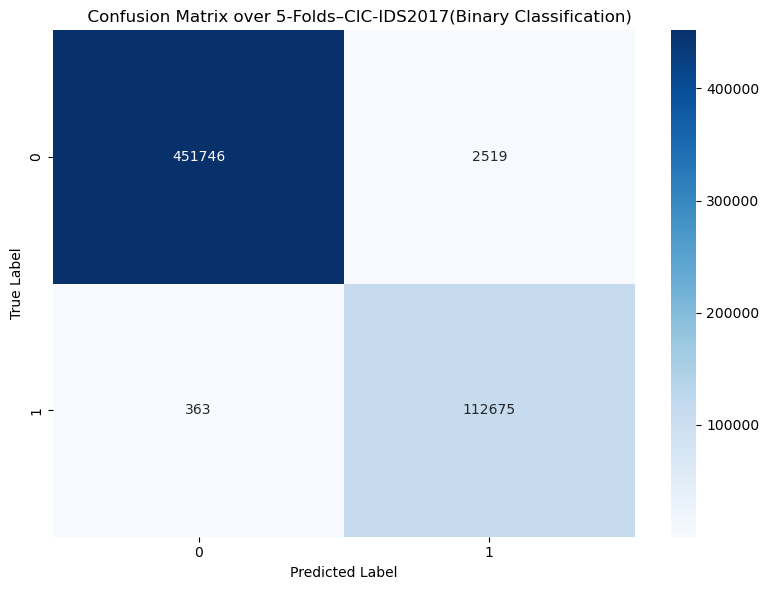

In [155]:
# --- Average Confusion Matrix (rounded to integers) ---
cm_avg_ensemble = np.mean(all_cm_ensemble, axis=0)
cm_avg_int = np.round(cm_avg).astype(int)  # Round to nearest integer

plt.figure(figsize=(8,6))
sns.heatmap(cm_avg_int, annot=True, fmt='d', cmap='Blues')

plt.title('      Confusion Matrix over 5-Folds–CIC-IDS2017(Binary Classification)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig("peerj_revision1_confusion_matrix_CICIDS2017_Binary_ensemble.png", dpi=1200)
plt.show()




In [97]:

# --- Classification Report ---

print("\nAverage Classification Report:(Dynamic Ensemble Model)")
print(classification_report(y_true, y_pred_ensemble))



Average Classification Report:(Dynamic Ensemble Model)
              precision    recall  f1-score   support

           0       1.00      0.99      1.00   2271323
           1       0.98      1.00      0.99    565189

    accuracy                           0.99   2836512
   macro avg       0.99      1.00      0.99   2836512
weighted avg       1.00      0.99      0.99   2836512



In [98]:
# --- Classification Report for CNN ---
print("\nAverage Classification Report:(CNN)")
print(classification_report(y_true, y_pred_cnn))


Average Classification Report:(CNN)
              precision    recall  f1-score   support

           0       0.88      0.99      0.93   2263537
           1       0.93      0.45      0.61    572975

    accuracy                           0.88   2836512
   macro avg       0.91      0.72      0.77   2836512
weighted avg       0.89      0.88      0.87   2836512



In [106]:
# --- Classification Report for LSTM ---
print("\nAverage Classification Report:(LSTM)")
print(classification_report(y_true, y_pred_lstm))


Average Classification Report:(LSTM)
              precision    recall  f1-score   support

           0       0.94      0.93      0.94   2263537
           1       0.73      0.78      0.76    572975

    accuracy                           0.90   2836512
   macro avg       0.84      0.86      0.85   2836512
weighted avg       0.90      0.90      0.90   2836512



In [101]:
# --- Classification Report for FNN ---
print("\nAverage Classification Report:(FNN)"
print(classification_report(y_true, y_pred_fnn))


Average Classification Report:(FNN)
              precision    recall  f1-score   support

           0       0.94      0.93      0.94   2263537
           1       0.73      0.78      0.76    572975

    accuracy                           0.90   2836512
   macro avg       0.84      0.86      0.85   2836512
weighted avg       0.90      0.90      0.90   2836512



In [112]:
y_true = np.concatenate(all_y_test)
y_pred_ensemble = np.concatenate(all_ensemble_pred)
y_prob_ensemble = np.concatenate(all_ensemble_prob)


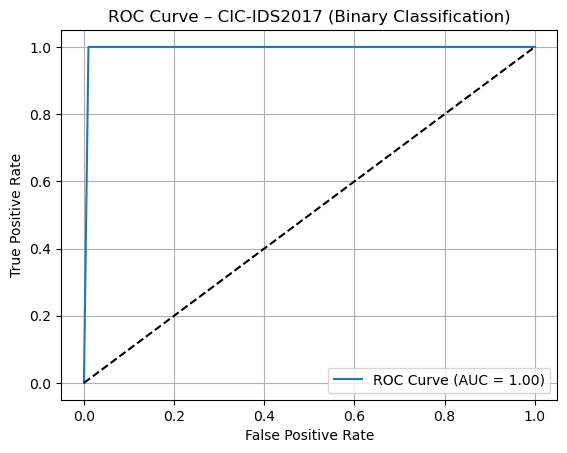

In [118]:
# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_true, y_prob_ensemble)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC Curve AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Over 5-Fold Cross-Validation–CIC-IDS2017(Binary Classification)')

plt.legend()
plt.savefig("peerj_revision1_ROCCurve_CIC-IDS2017_Binary_ensemble.png",dpi=1200)
plt.show()



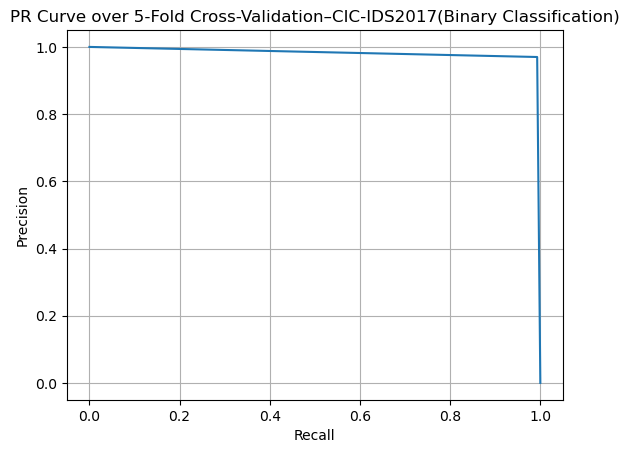

In [127]:

# --- Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_true, y_prob_ensemble)

plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve over 5-Fold Cross-Validation–CIC-IDS2017(Binary Classification)')
plt.grid()
plt.savefig("peerj_revision1_PRCurve_CICIDS2017_Binary_ensemble.png", dpi=1200)
plt.show()


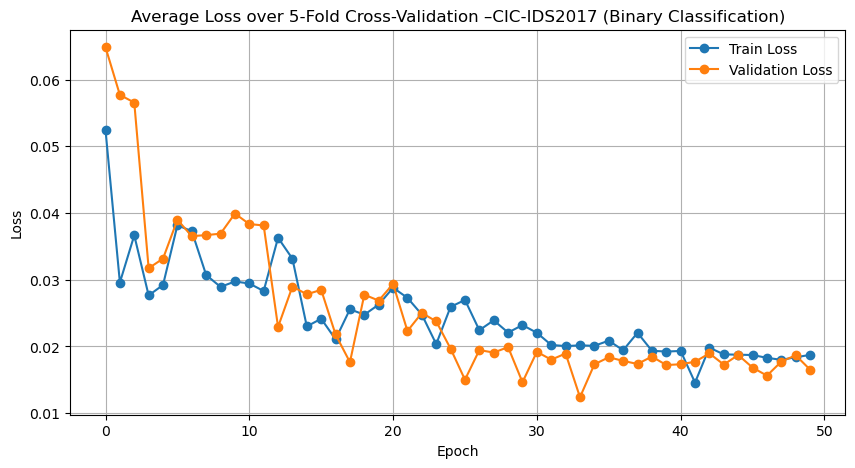

In [133]:
plt.figure(figsize=(10, 5))
plt.plot(ensemble_history.history['loss'], label='Train Loss', marker='o')
plt.plot(ensemble_history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Average Loss over 5-Fold Cross-Validation –CIC-IDS2017 (Binary Classification)')
plt.grid(True)
plt.savefig("peerj_revision1_CIC-IDS2017_loss_binary.png",dpi=1200)
plt.show()

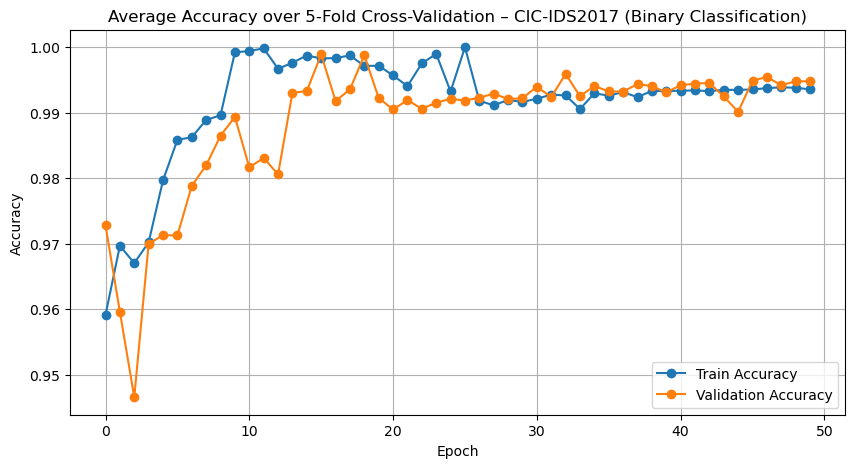

In [138]:
# Evaluate the model and visualize results
# Accuracy and loss plots
plt.figure(figsize=(10, 5))
plt.plot(ensemble_history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(ensemble_history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Average Accuracy over 5-Fold Cross-Validation – CIC-IDS2017 (Binary Classification)')
plt.grid(True)
plt.savefig("Peerj_revision1_CIC-IDS2017_Accuracy_binary.png",dpi=1200)
plt.show()

In [145]:
# Extract and plot attention weights
attention_model = Model(inputs=ensemble_model.inputs, outputs=ensemble_model.get_layer('attention_weights').output)
attention_weights_test = attention_model.predict([X_test_cnn, X_test_cnn, X_test],verbose=0)



In [146]:
from tensorflow.keras.models import Model
import pandas as pd

# Extract the attention model
attention_model = Model(inputs=ensemble_model.inputs, outputs=ensemble_model.get_layer('attention_weights').output)

# Predict attention weights for the full test set
attention_vals = attention_model.predict([X_test_cnn, X_test_cnn, X_test],verbose=0)

avg_attention = np.mean(attention_vals, axis=0)

# Create DataFrame for plotting
attention_df = pd.DataFrame({
    'Feature': [f'Feature {i+1}' for i in range(len(avg_attention))],
    'Attention Weight': avg_attention
})

In [147]:
# Assuming df_selected.columns contains the real feature names
feature_names = [ 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Std',
    'Bwd Packet Length Min', 'Bwd Packet Length Std', 'Flow IAT Std', 'Flow IAT Max',
    'Flow IAT Min', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Mean', 'Bwd IAT Max',
    'Bwd IAT Min', 'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length',
    'Bwd Packets/s', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Variance',
    'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count',
    'URG Flag Count', 'CWE Flag Count', 'Down/Up Ratio', 'Average Packet Size',
    'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Packets',
    'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Active Mean', 'Active Max',
    'Active Min', 'Idle Std'
]

# Create a DataFrame for visualization with actual feature names
attention_df = pd.DataFrame({
    'Feature': feature_names,
    'Attention Weight': avg_attention
})

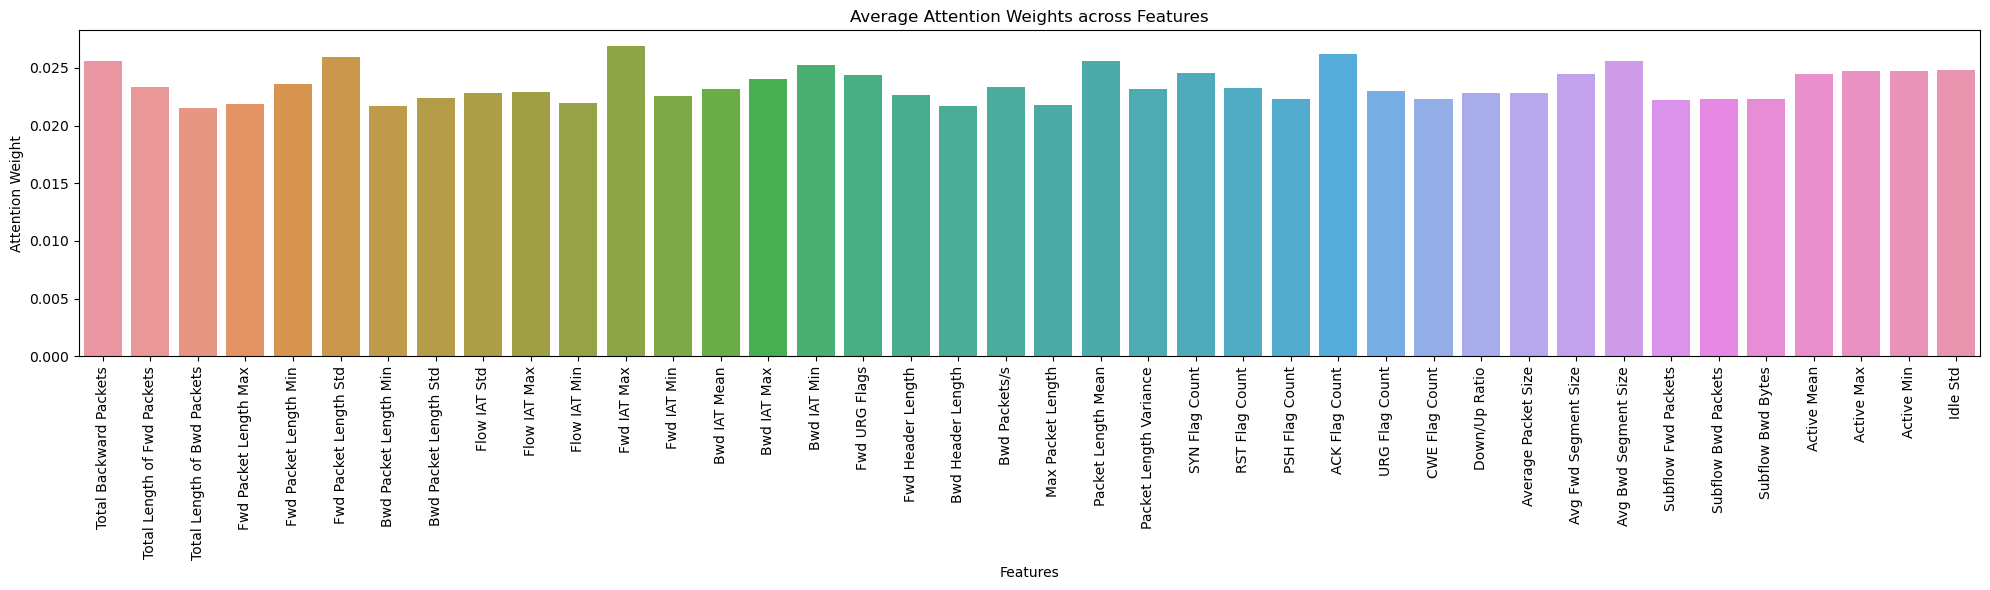

In [150]:
# Plot
plt.figure(figsize=(20, 6))
sns.barplot(x='Feature', y='Attention Weight', data=attention_df)
plt.title('Average Attention Weights across Features')
plt.xlabel('Features')
plt.ylabel('Attention Weight')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("peerj_revision1_CICIDS2017_Binary_attention_ensemble.png",dpi=1200)
plt.show()

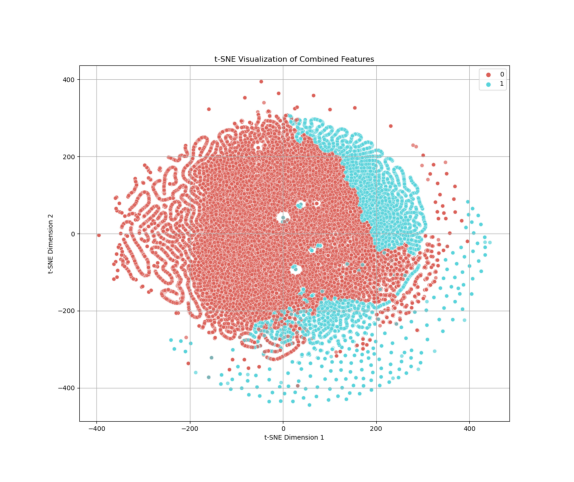

In [154]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Stack all test data and labels from the folds
X_tsne = np.vstack([X[test_idx] for _, test_idx in kfold.split(X, y)])
y_tsne = np.hstack(all_y_test)  # ground truth labels

# Reduce dimensionality with t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=50)
X_embedded = tsne.fit_transform(X_tsne)

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_embedded[:, 0], y=X_embedded[:, 1], hue=y_tsne, palette='coolwarm', s=10)
plt.title('t-SNE Visualization of Combined Features')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Class', loc='best')
plt.tight_layout()

# Save it again with higher DPI


plt.savefig("peerj_revision1_tSNE_CICIDS2017_binary.png", dpi=(1200,1200)
plt.show()

